In [7]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
# Set backend before importing keras
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import keras_cv
from keras import ops
import tensorflow as tf
from tensorflow.keras import layers, models

import h5py
import cv2
import joblib
from glob import glob
from tqdm.notebook import tqdm
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

# Configuration class
class CFG:
    seed = 42
    preset = "efficientnetv2_b0_imagenet" 
    image_size = [256, 256] 
    batch_size = 16
    epochs = 10
    
    # Adding training hyperparameters for medical imaging
    lr = 1e-4
    patience = 3
    # Critical for ISIC 2024: Control the ratio of positive vs negative samples
    pos_ratio = 0.2 

# Set global seed for reproducibility
keras.utils.set_random_seed(CFG.seed)

# Define paths
base_path = "/kaggle/input/competitions/isic-2024-challenge"
train_metadata_path = os.path.join(base_path, "train-metadata.csv")
train_h5_path = os.path.join(base_path, "train-image.hdf5")

# Detect hardware accelerators
devices = tf.config.list_physical_devices('GPU')
if devices:
    print(f"GPUs detected: {len(devices)}")
    # Enable mixed precision for faster training if supported
    keras.mixed_precision.set_global_policy("mixed_float16")
else:
    print("Training on CPU")

Training on CPU


In [5]:
# 1. Load metadata
# Using a more surgical approach to missing values
df_train = pd.read_csv(f'{base_path}/train-metadata.csv', low_memory=False)

# Basic imputation: fill numeric with -1 and categorical with 'unknown'
# This prevents ffill() from leaking data between unrelated patient rows
df_train['age_approx'] = df_train['age_approx'].fillna(-1)
df_train['sex'] = df_train['sex'].fillna('unknown')

# 2. Stratified Split (CRITICAL: Before upsampling/downsampling)
# We split by 'target' to ensure both sets have positive cases
train_indices, val_indices = train_test_split(
    df_train.index, 
    test_size=0.2, 
    stratify=df_train['target'], 
    random_state=CFG.seed
)

df_train_raw = df_train.loc[train_indices].reset_index(drop=True)
df_val = df_train.loc[val_indices].reset_index(drop=True)

# 3. Balancing only the Training Set
df_positive = df_train_raw[df_train_raw['target'] == 1]
df_negative = df_train_raw[df_train_raw['target'] == 0]

# Upsampling positives to reach a specific count
target_positive_count = 50000 
df_pos_upsampled = resample(
    df_positive, 
    replace=True, 
    n_samples=target_positive_count, 
    random_state=CFG.seed
)

# Downsampling negatives to balance the ratio
target_negative_count = 50000
df_neg_downsampled = resample(
    df_negative, 
    replace=False, 
    n_samples=target_negative_count, 
    random_state=CFG.seed
)

# 4. Combine and Shuffle
df_train_balanced = pd.concat([df_pos_upsampled, df_neg_downsampled])
df_train_balanced = df_train_balanced.sample(frac=1, random_state=CFG.seed).reset_index(drop=True)

# Report results
print(f"--- Dataset Statistics ---")
print(f"Training set (Balanced): {len(df_train_balanced)} samples")
print(f"Validation set (Original distribution): {len(df_val)} samples")
print(f"Positives in Validation: {df_val['target'].sum()}")

# Clean up memory
import gc
del df_train, df_positive, df_negative, df_pos_upsampled, df_neg_downsampled
gc.collect()

--- Dataset Statistics ---
Training set (Balanced): 100000 samples
Validation set (Original distribution): 80212 samples
Positives in Validation: 79


0

Final training samples: 100000
Final validation samples: 80212
HDF5 file contains 401059 images.


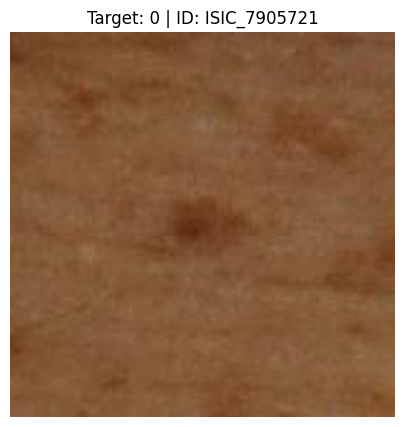

In [5]:
# 1. Verification and Setup
# Note: We use the df_val from the previous step which was separated 
# BEFORE upsampling to ensure a clean validation.
print(f"Final training samples: {len(df_train_balanced)}")
print(f"Final validation samples: {len(df_val)}")

# 2. Open HDF5 file
# We open it in read mode to access the image data
hdf5_file = h5py.File(os.path.join(base_path, "train-image.hdf5"), "r")

# Check synchronization using the original file length if needed
# but more importantly, verify we can access images by isic_id
total_images = len(hdf5_file)
print(f"HDF5 file contains {total_images} images.")

# 3. Helper function to get image from HDF5
# This is more efficient than loading everything into memory
def get_image(isic_id, file_handler):
    """
    Retrieves and decodes an image from the HDF5 file using its ISIC ID.
    """
    # Images in this HDF5 are stored as byte strings (encoded as .jpg)
    raw_data = file_handler[isic_id][()]
    
    # Decode the bytes into a numpy array (image)
    image = cv2.imdecode(np.frombuffer(raw_data, np.uint8), cv2.IMREAD_COLOR)
    
    # Convert BGR (OpenCV default) to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    return image

# 4. Sanity check: Plot a sample from our balanced dataframe
sample_row = df_train_balanced.iloc[0]
sample_img = get_image(sample_row['isic_id'], hdf5_file)

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.title(f"Target: {sample_row['target']} | ID: {sample_row['isic_id']}")
plt.axis('off')
plt.show()

In [6]:
def preprocess_tabular_data(df_train, df_val):
    """
    Preprocesses tabular data for both training and validation sets 
    ensuring consistent scaling and encoding.
    """
    cat_features = [
        'sex', 'anatom_site_general', 'tbp_tile_type', 
        'tbp_lv_location', 'tbp_lv_location_simple'
    ]
    num_features = [
        'age_approx', 'clin_size_long_diam_mm', 'tbp_lv_areaMM2', 
        'tbp_lv_perimeterMM', 'tbp_lv_eccentricity', 'tbp_lv_stdLExt'
    ]
    
    # Process Categorical
    for col in cat_features:
        # Fill missing with 'unknown'
        df_train[col] = df_train[col].fillna('unknown')
        df_val[col] = df_val[col].fillna('unknown')
        
        # Fit factorize on training and map to validation
        labels, uniques = pd.factorize(df_train[col])
        df_train[f'{col}_enc'] = labels
        
        # Create a mapping for validation
        mapping = {val: i for i, val in enumerate(uniques)}
        df_val[f'{col}_enc'] = df_val[col].map(mapping).fillna(-1).astype(int)
        
    # Process Numerical
    for col in num_features:
        # 1. Fill NA with training median (avoiding leakage from val)
        median_val = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_val)
        df_val[col] = df_val[col].fillna(median_val)
        
        # 2. Min-Max Scaling based ONLY on training stats
        c_min = df_train[col].min()
        c_max = df_train[col].max()
        
        # Avoid division by zero
        denom = (c_max - c_min) if (c_max - c_min) != 0 else 1
        
        df_train[f'{col}_norm'] = (df_train[col] - c_min) / denom
        df_val[f'{col}_norm'] = (df_val[col] - c_min) / denom

    # Define final columns
    final_feature_cols = [f'{c}_enc' for c in cat_features] + [f'{c}_norm' for c in num_features]
    
    # Extract arrays
    train_tabular = df_train[final_feature_cols].values.astype(np.float32)
    val_tabular = df_val[final_feature_cols].values.astype(np.float32)
    
    return train_tabular, val_tabular, final_feature_cols

# Executing the refined preprocessing
# Using the split we did before upsampling (df_train_balanced and df_val)
train_tab, val_tab, feature_names = preprocess_tabular_data(df_train_balanced, df_val)

print(f"Tabular features ready: {len(feature_names)}")
print(f"Sample from training tabular features:\n{train_tab[0]}")

Tabular features ready: 11
Sample from training tabular features:
[0.         0.         0.         0.         0.         0.7093023
 0.06425703 0.01124923 0.05266184 0.7211791  0.04179654]


In [7]:
def build_augmentation_pipeline():
    """
    Defines the image augmentation strategy using KerasCV layers.
    Handles inputs as a dictionary to avoid string unpacking errors.
    """
    augmenter = keras_cv.layers.Augmenter([
        keras_cv.layers.RandomFlip(mode="horizontal_and_vertical"),
        keras_cv.layers.RandomRotation(factor=0.1), 
        keras_cv.layers.RandomBrightness(factor=0.1, value_range=(0, 1)),
        keras_cv.layers.RandomContrast(value_range=(0, 1), factor=0.1),
        keras_cv.layers.RandomCutout(height_factor=(0.02, 0.06), width_factor=(0.02, 0.06)),
    ])

    def apply_augmentation(inputs, label):
        # inputs is a dictionary: {"images": tensor, "tabular": tensor}
        # We pass only the image tensor to the augmenter
        inputs["images"] = augmenter(inputs["images"])
        
        # Return the modified dictionary and the label
        return inputs, label

    return apply_augmentation

# Instantiate the function
augment_fn = build_augmentation_pipeline()

In [8]:
def build_decoder(with_labels=True, target_size=CFG.image_size):
    def decode_image(file_bytes):
        image = tf.io.decode_jpeg(file_bytes, channels=3)
        image = tf.image.resize(image, size=target_size, method="area")
        image = tf.cast(image, tf.float32) / 255.0
        
        # --- LÍNEA CRUCIAL PARA CORREGIR EL ERROR ---
        # Esto le devuelve al tensor la información de dimensiones que KerasCV necesita
        image.set_shape([target_size[0], target_size[1], 3])
        
        return image

    def decode_with_labels(image_bytes, tabular_features, label=None):
        inputs = {
            "images": decode_image(image_bytes),
            "tabular": tf.cast(tabular_features, tf.float32)
        }
        # También fijamos el shape de los datos tabulares por seguridad
        inputs["tabular"].set_shape([11]) 
        
        if label is not None:
            label = tf.cast(label, tf.float32)
            label = tf.reshape(label, [1])
            return inputs, label
        
        return inputs

    return decode_with_labels if with_labels else decode_image

# 1. Re-instancia la función
decode_fn = build_decoder(with_labels=True)

In [9]:
def build_dataset(df, tabular_data, labels=None, batch_size=32, 
                  decode_fn=None, augment_fn=None, 
                  shuffle=False, cache=False, augment=False):
    """
    Creates a high-performance tf.data.Dataset for Multimodal learning
    extracting images from HDF5 on the fly.
    """
    
    # 1. Prepare data sources
    isic_ids = df['isic_id'].values
    
    # Helper to get raw bytes from HDF5 (needed because HDF5 isn't natively 
    # iterable by TensorFlow datasets easily)
    def get_h5_data(isic_id):
        # Convertimos el tensor a numpy y luego a string de forma segura
        if hasattr(isic_id, "numpy"):
            isic_id = isic_id.numpy()
        
        # Si es un objeto de bytes (b'ISIC_...'), lo decodificamos a string
        if isinstance(isic_id, bytes):
            isic_id = isic_id.decode("utf-8")
            
        return hdf5_file[isic_id][()]

   
    def py_func_get_image(isic_id, tab, label=None):
        # Wrap the H5 access in a numpy function
        img_bytes = get_h5_data(isic_id)
        if label is not None:
            return img_bytes, tab, label
        return img_bytes, tab

    # 2. Create the initial Dataset from IDs and Tabular arrays
    if labels is not None:
        ds = tf.data.Dataset.from_tensor_slices((isic_ids, tabular_data, labels))
        # Map the H5 retrieval
        ds = ds.map(lambda i, t, l: tf.py_function(
            py_func_get_image, [i, t, l], [tf.string, tf.float32, tf.float32]),
            num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = tf.data.Dataset.from_tensor_slices((isic_ids, tabular_data))
        ds = ds.map(lambda i, t: tf.py_function(
            py_func_get_image, [i, t], [tf.string, tf.float32]),
            num_parallel_calls=tf.data.AUTOTUNE)

    # 3. Decoding: Convert bytes to pixels via our decode_fn
    # We must ensure decode_fn accepts (bytes, tab, label)
    if decode_fn:
        ds = ds.map(decode_fn, num_parallel_calls=tf.data.AUTOTUNE)

    # 4. Caching: Use with caution. 100k images + 256x256 will crash RAM.
    # Suggestion: Only cache if image_size is very small or you have 30GB+ RAM.
    if cache:
        ds = ds.cache()

    # 5. Shuffling and Augmentation
    if shuffle:
        ds = ds.shuffle(2048)
        ds = ds.repeat()

    if augment and augment_fn:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    # 6. Batching & Prefetching
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

# Creating the final datasets for training
train_ds = build_dataset(
    df_train_balanced, train_tab, labels=df_train_balanced['target'].values,
    batch_size=CFG.batch_size, decode_fn=decode_fn, augment_fn=augment_fn,
    shuffle=True, augment=True, cache=False
)

val_ds = build_dataset(
    df_val, val_tab, labels=df_val['target'].values,
    batch_size=CFG.batch_size, decode_fn=decode_fn,
    shuffle=False, augment=False, cache=False
)

In [10]:
# Convertimos etiquetas y tablas a float32 explícitamente
train_labels_f32 = df_train_balanced['target'].values.astype(np.float32)
val_labels_f32 = df_val['target'].values.astype(np.float32)

# train_tab y val_tab ya deberían ser float32 por el bloque de preprocesamiento, 
# pero lo aseguramos por si acaso:
train_tab = train_tab.astype(np.float32)
val_tab = val_tab.astype(np.float32)

# Ahora instanciamos con estos nuevos objetos
train_ds = build_dataset(
    df=df_train_balanced,
    tabular_data=train_tab,
    labels=train_labels_f32,
    batch_size=CFG.batch_size,
    decode_fn=decode_fn,
    augment_fn=augment_fn,
    shuffle=True,
    augment=True,
    cache=False 
)

val_ds = build_dataset(
    df=df_val,
    tabular_data=val_tab,
    labels=val_labels_f32,
    batch_size=CFG.batch_size,
    decode_fn=decode_fn,
    shuffle=False,
    augment=False,
    cache=False
)

In [11]:
def build_multimodal_model(input_shape=(256, 256, 3), num_features=11):
    # --- BRANCH 1: VISION (Images) ---
    input_image = layers.Input(shape=input_shape, name="images")
    
    # Using EfficientNetB0 as the base (Backbone)
    # include_top=False means we don't use the original classification head
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, 
        weights="imagenet", 
        input_tensor=input_image,
        pooling="avg" # This converts the last feature map into a single vector
    )
    # We allow the model to fine-tune its knowledge
    base_model.trainable = True 
    
    vision_output = base_model.output

    # --- BRANCH 2: TABULAR (Metadata) ---
    input_tabular = layers.Input(shape=(num_features,), name="tabular")
    
    # A small neural network for the numbers
    tabular_branch = layers.Dense(16, activation="relu")(input_tabular)
    tabular_branch = layers.Dense(16, activation="relu")(tabular_branch)
    
    # --- FUSION: Combining both worlds ---
    concat = layers.Concatenate()([vision_output, tabular_branch])
    
    # Final Classification Layers
    x = layers.Dense(32, activation="relu")(concat)
    x = layers.Dropout(0.2)(x) # Prevents overfitting
    output = layers.Dense(1, activation="sigmoid", name="output")(x)
    
    # Define the final model with 2 inputs and 1 output
    model = models.Model(inputs=[input_image, input_tabular], outputs=output)
    
    return model

# Create the model instance
model = build_multimodal_model(num_features=len(feature_names))

# Let's see the architecture
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ images[0][0]      │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 4,091,572 (15.61 MB)

 Trainable params: 4,049,549 (15.45 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [12]:
# 1. Optimizer con Learning Rate dinámico
initial_lr = 0.0001
optimizer = tf.keras.optimizers.Adam(learning_rate=initial_lr)

# 2. Loss Function
# El label_smoothing es clave para la generalización en ISIC
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05) 

# 3. Compilation
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        # Agregamos Precision y Recall porque el Accuracy engaña mucho en desbalance
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# 4. Callbacks (El "seguro de vida" de tu modelo)
# Reducción de LR si hay estancamiento
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc', # Cambiamos a val_auc: es más estable que val_loss para el pAUC final
    mode='max',
    factor=0.2, # Reducción más agresiva
    patience=2, 
    verbose=1
)

# Guardar el MEJOR modelo (Checkpoint)
# Crucial en Kaggle por si se corta la sesión o si el modelo empieza a empeorar
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_isic_model.keras",
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Early Stopping: para no perder tiempo si el modelo ya no da más
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

print("Model compiled with advanced callbacks. Ready for the long run.")

Model compiled with advanced callbacks. Ready for the long run.


In [13]:
# 1. Preparamos los metadatos de validación (usando el df_val original, sin balancear)
# Nota: 'val_tab' es el resultado que generamos en el bloque de preprocesamiento tabular
val_labels = df_val['target'].values

# 2. Construimos el Dataset de ENTRENAMIENTO
# Usamos el set balanceado para que el modelo aprenda a ver el cáncer
train_ds = build_dataset(
    df=df_train_balanced,
    tabular_data=train_tab,
    labels=df_train_balanced['target'].values,
    batch_size=CFG.batch_size,
    decode_fn=decode_fn,
    augment_fn=augment_fn,
    shuffle=True,
    augment=True,
    cache=False 
)

# 3. Construimos el Dataset de VALIDACIÓN
# Usamos el set original para tener una métrica REAL de competencia
val_ds = build_dataset(
    df=df_val,
    tabular_data=val_tab,
    labels=val_labels,
    batch_size=CFG.batch_size,
    decode_fn=decode_fn,
    shuffle=False,
    augment=False,
    cache=False
)

print(f"Datasets ready. Train steps per epoch: {len(df_train_balanced)//CFG.batch_size}")
print(f"Validation steps: {len(df_val)//CFG.batch_size}")

Datasets ready. Train steps per epoch: 6250
Validation steps: 5013


In [14]:
# 1. Definimos la duración
# Para un backbone como EfficientNetB0, 10-15 épocas suelen bastar con este dataset balanceado
EPOCHS = CFG.epochs if hasattr(CFG, 'epochs') else 15 

# 2. Calculamos los pasos exactos
steps_per_epoch = len(df_train_balanced) // CFG.batch_size
validation_steps = len(df_val) // CFG.batch_size

print(f"🚀 Iniciando entrenamiento...")
print(f"Pasos por época: {steps_per_epoch}")

# 3. Lanzamiento del entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[
        checkpoint_cb,    # Guarda el mejor modelo automáticamente
        lr_callback,      # Baja el LR si el AUC se estanca
        early_stop_cb     # Corta el entrenamiento si ya no mejora
    ],
    verbose=1
)

# Guardar el modelo final al terminar (opcional, el mejor ya estará en 'best_isic_model.keras')
model.save("final_isic_model_v1.keras")
print("✅ Entrenamiento completado y modelo guardado.")

🚀 Iniciando entrenamiento...
Pasos por época: 6250
Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node EagerPyFunc defined at (most recent call last):
<stack traces unavailable>
Error in user-defined function passed to ParallelMapDatasetV2:27 transformation with iterator: Iterator::Root::Prefetch::MapAndBatch::ShuffleAndRepeat::ParallelMapV2::ParallelMapV2: ValueError: Tensor conversion requested dtype float32 for Tensor with dtype int64: <tf.Tensor: shape=(), dtype=int64, numpy=0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 267, in __call__
    return func(device, token, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 145, in __call__
    outputs = self._call(device, args)
              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 162, in _call
    _maybe_copy_to_context_device(self._co